# Componente 2 -- Sistema de deteccion en dos etapas

Proyecto 2 -- CC3092 Deep Learning

Parte de account_events.parquet y account_labels_splits.parquet generados en el Componente 1 (secuencias por cuenta, no por remitente).

Etapa A: autoencoder LSTM entrenado solo sobre cuentas normales. El error de reconstruccion es el score de anomalia.

Etapa B: clasificador supervisado que reutiliza el encoder de la Etapa A via transfer learning (Semana 9), combinando la representacion aprendida con el score de anomalia en una prediccion final.

Ablation obligatorio: se compara el sistema de dos etapas contra un clasificador identico entrenado desde cero.

## 0. Setup

In [1]:
import copy
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_recall_curve,
    f1_score, precision_score, recall_score,
)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

DATA_PROCESSED = Path("../data/processed")

Device: cpu


## 1. Construccion de tensores de secuencia

Vector por evento, 12 dimensiones: one-hot del tipo (5), direccion (1), 5 features continuas estandarizadas, y flag de estructuracion (1). Se usa one-hot en vez de embedding porque el autoencoder reconstruye este vector con MSE, y un embedding entrenable complicaria la reconstruccion sin aportar beneficio en solo 5 categorias.

Las secuencias se truncan a MAX_SEQ_LEN (27, el percentil 95), priorizando el comportamiento mas reciente. El padding se hace por batch.

In [2]:
events = pd.read_parquet(DATA_PROCESSED / "account_events.parquet")
labels = pd.read_parquet(DATA_PROCESSED / "account_labels_splits.parquet")

MAX_SEQ_LEN = 27
FEATURE_COLS = ["log_amount_z", "hour_sin_z", "hour_cos_z", "log_delta_t_z", "frac_balance_z"]
N_TYPES = 5
INPUT_DIM = N_TYPES + 1 + len(FEATURE_COLS) + 1  # = 12

events = events.sort_values(["account", "step"]).reset_index(drop=True)

type_onehot = np.zeros((len(events), N_TYPES), dtype=np.float32)
type_onehot[np.arange(len(events)), events["type_code"].values] = 1.0

feat_matrix = np.concatenate([
    type_onehot,
    events[["direction"]].values.astype(np.float32),
    events[FEATURE_COLS].values.astype(np.float32),
    events[["near_threshold"]].values.astype(np.float32),
], axis=1)
print("feat_matrix shape:", feat_matrix.shape, "| INPUT_DIM:", INPUT_DIM)

account_row_idx = events.groupby("account", sort=False).indices  # account -> array de posiciones

sequences = {}
for acc, idx in account_row_idx.items():
    seq = feat_matrix[idx]
    if len(seq) > MAX_SEQ_LEN:
        seq = seq[-MAX_SEQ_LEN:]
    sequences[acc] = seq

print(f"Cuentas con secuencia construida: {len(sequences):,}")

feat_matrix shape: (944283, 12) | INPUT_DIM: 12


Cuentas con secuencia construida: 105,529


In [3]:
class AccountSeqDataset(Dataset):
    def __init__(self, account_ids, sequences, labels_map):
        self.account_ids = list(account_ids)
        self.sequences = sequences
        self.labels_map = labels_map

    def __len__(self):
        return len(self.account_ids)

    def __getitem__(self, i):
        acc = self.account_ids[i]
        seq = torch.from_numpy(self.sequences[acc])
        label = float(self.labels_map[acc])
        return acc, seq, label


def collate_fn(batch):
    accs, seqs, labs = zip(*batch)
    lengths = torch.tensor([s.shape[0] for s in seqs], dtype=torch.long)
    padded = pad_sequence(seqs, batch_first=True)  # (B, Tmax, INPUT_DIM)
    labs = torch.tensor(labs, dtype=torch.float32)
    return list(accs), padded, lengths, labs


labels_map = labels.set_index("account")["has_fraud"].to_dict()
split_map = labels.set_index("account")["split"].to_dict()

train_accs = labels.loc[labels["split"] == "train", "account"].tolist()
val_accs = labels.loc[labels["split"] == "val", "account"].tolist()
test_accs = labels.loc[labels["split"] == "test", "account"].tolist()

train_normal_accs = [a for a in train_accs if labels_map[a] == 0]
print(f"Train total: {len(train_accs):,} | Train normal (Etapa A): {len(train_normal_accs):,}")
print(f"Val: {len(val_accs):,} | Test: {len(test_accs):,}")

Train total: 73,870 | Train normal (Etapa A): 70,000
Val: 15,829 | Test: 15,830


## 2. Etapa A: autoencoder LSTM, aprendizaje de la normalidad

Arquitectura: LSTM encoder-decoder. El encoder procesa la secuencia con pack_padded_sequence, y su estado oculto final es la representacion comprimida z. El decoder reconstruye la secuencia a partir de z.

Se usa LSTM en vez de Transformer o MLP porque las secuencias son cortas (mediana 6, p95=27) y basta con capturar dependencias de orden; es tambien el enfoque mas directo con lo visto en el curso.

Entrenamiento: solo con cuentas has_fraud == 0 del split de train, para que el error de reconstruccion en validacion o prueba refleje que tan distinta es una secuencia de lo normal.

In [4]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, hidden_dim=64):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.encoder = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.decoder = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.output_layer = nn.Linear(hidden_dim, input_dim)

    def encode(self, x, lengths):
        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.encoder(packed)
        return h_n[-1]  # (B, hidden_dim)

    def forward(self, x, lengths):
        B, T, _ = x.shape
        z = self.encode(x, lengths)
        decoder_input = z.unsqueeze(1).repeat(1, T, 1)
        packed_dec_in = pack_padded_sequence(decoder_input, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_dec_out, _ = self.decoder(packed_dec_in)
        out, _ = pad_packed_sequence(packed_dec_out, batch_first=True, total_length=T)
        recon = self.output_layer(out)
        return recon, z


def sequence_mask(lengths, T, device):
    return (torch.arange(T, device=device)[None, :] < lengths[:, None].to(device)).float()


def masked_mse_loss(recon, target, lengths):
    B, T, D = target.shape
    mask = sequence_mask(lengths, T, target.device).unsqueeze(-1)
    se = (recon - target) ** 2 * mask
    return se.sum() / (mask.sum() * D)


def per_sample_recon_error(recon, target, lengths):
    B, T, D = target.shape
    mask = sequence_mask(lengths, T, target.device).unsqueeze(-1)
    se = (recon - target) ** 2 * mask
    return se.sum(dim=(1, 2)) / (lengths.float().to(target.device) * D)

In [5]:
train_normal_ds = AccountSeqDataset(train_normal_accs, sequences, labels_map)
val_ds = AccountSeqDataset(val_accs, sequences, labels_map)

train_normal_loader = DataLoader(train_normal_ds, batch_size=256, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=512, shuffle=False, collate_fn=collate_fn)

autoencoder = LSTMAutoencoder(hidden_dim=64).to(DEVICE)
opt_ae = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)

N_EPOCHS_AE = 15
history_ae = {"train_loss": [], "val_loss_normal": []}

t0 = time.time()
for epoch in range(1, N_EPOCHS_AE + 1):
    autoencoder.train()
    total_loss, n_batches = 0.0, 0
    for accs, x, lengths, y in train_normal_loader:
        x = x.to(DEVICE)
        opt_ae.zero_grad()
        recon, _ = autoencoder(x, lengths)
        loss = masked_mse_loss(recon, x, lengths)
        loss.backward()
        opt_ae.step()
        total_loss += loss.item()
        n_batches += 1
    train_loss = total_loss / n_batches

    autoencoder.eval()
    val_losses = []
    with torch.no_grad():
        for accs, x, lengths, y in val_loader:
            x = x.to(DEVICE)
            normal_mask = (y == 0)
            if normal_mask.sum() == 0:
                continue
            recon, _ = autoencoder(x, lengths)
            err = per_sample_recon_error(recon, x, lengths)
            val_losses.append(err[normal_mask].mean().item())
    val_loss = float(np.mean(val_losses))

    history_ae["train_loss"].append(train_loss)
    history_ae["val_loss_normal"].append(val_loss)
    print(f"Epoch {epoch:2d}/{N_EPOCHS_AE} | train MSE: {train_loss:.4f} | val MSE (solo normales): {val_loss:.4f}")

print(f"\nTiempo total: {time.time()-t0:.1f}s")

Epoch  1/15 | train MSE: 0.3891 | val MSE (solo normales): 0.3429


Epoch  2/15 | train MSE: 0.3185 | val MSE (solo normales): 0.2810


Epoch  3/15 | train MSE: 0.2877 | val MSE (solo normales): 0.2421


Epoch  4/15 | train MSE: 0.2650 | val MSE (solo normales): 0.2125


Epoch  5/15 | train MSE: 0.2493 | val MSE (solo normales): 0.1953


...

Epoch 11/15 | train MSE: 0.2057 | val MSE (solo normales): 0.1454


Epoch 12/15 | train MSE: 0.2008 | val MSE (solo normales): 0.1395


Epoch 13/15 | train MSE: 0.1961 | val MSE (solo normales): 0.1351


Epoch 14/15 | train MSE: 0.1919 | val MSE (solo normales): 0.1301


Epoch 15/15 | train MSE: 0.1894 | val MSE (solo normales): 0.1278

Tiempo total: 606.5s


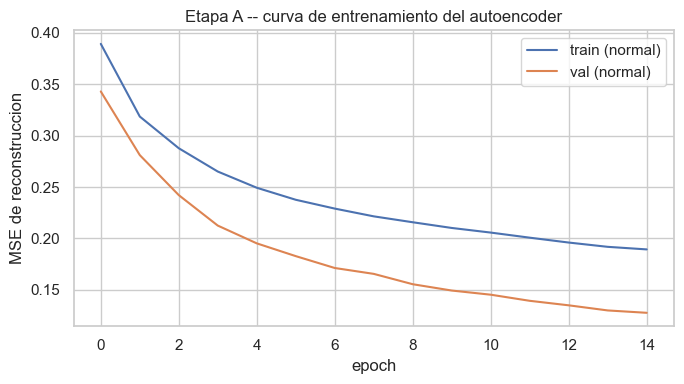

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history_ae["train_loss"], label="train (normal)")
ax.plot(history_ae["val_loss_normal"], label="val (normal)")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE de reconstruccion")
ax.set_title("Etapa A -- curva de entrenamiento del autoencoder")
ax.legend()
plt.tight_layout()
plt.show()

### 2.1 Seleccion de umbral sobre el error de reconstruccion

Se calcula el error de reconstruccion en todo el split de validacion (usando la etiqueta solo para evaluar el umbral, nunca para entrenar). Se elige el umbral que maximiza F1 sobre la curva precision-recall.

Umbral elegido (maximiza F1 en val): 0.2391
En ese punto -> precision: 0.136, recall: 0.306, F1: 0.189
AP (PR-AUC) de la Etapa A sola sobre val: 0.1227


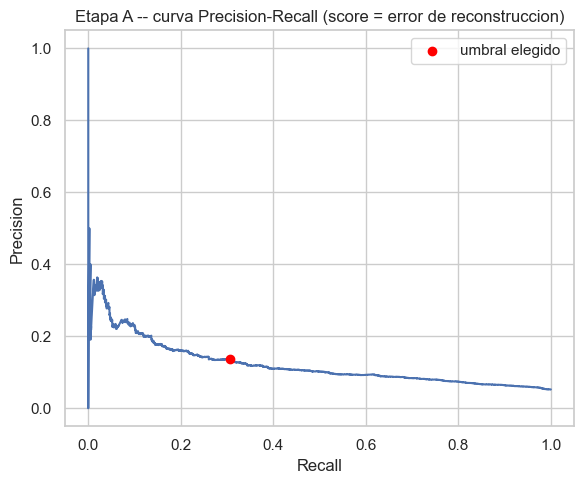

In [7]:
def compute_recon_errors(model, loader):
    model.eval()
    accs_all, errs_all, labs_all = [], [], []
    with torch.no_grad():
        for accs, x, lengths, y in loader:
            x = x.to(DEVICE)
            recon, _ = model(x, lengths)
            err = per_sample_recon_error(recon, x, lengths)
            accs_all.extend(accs)
            errs_all.extend(err.cpu().numpy().tolist())
            labs_all.extend(y.numpy().tolist())
    return pd.DataFrame({"account": accs_all, "recon_error": errs_all, "has_fraud": labs_all})

val_scores = compute_recon_errors(autoencoder, val_loader)

precisions, recalls, thresholds = precision_recall_curve(val_scores["has_fraud"], val_scores["recon_error"])
f1s = 2 * precisions * recalls / (precisions + recalls + 1e-12)
best_idx = np.nanargmax(f1s[:-1])  # thresholds tiene un elemento menos que precisions/recalls
best_threshold = thresholds[best_idx]

print(f"Umbral elegido (maximiza F1 en val): {best_threshold:.4f}")
print(f"En ese punto -> precision: {precisions[best_idx]:.3f}, recall: {recalls[best_idx]:.3f}, F1: {f1s[best_idx]:.3f}")
print(f"AP (PR-AUC) de la Etapa A sola sobre val: {average_precision_score(val_scores['has_fraud'], val_scores['recon_error']):.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(recalls, precisions)
ax.scatter([recalls[best_idx]], [precisions[best_idx]], color="red", zorder=5, label="umbral elegido")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Etapa A -- curva Precision-Recall (score = error de reconstruccion)")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Etapa B: clasificador supervisado con transfer learning

Se prueban 3 estrategias de adaptacion del encoder heredado (Semana 9), cada una 20 epochs:

| Estrategia | LR encoder | LR cabeza | val AP (PR-AUC) |
|---|---|---|---|
| Feature extraction, encoder congelado | 0 | 2e-3 | 0.363 |
| Fine-tuning discriminativo conservador | 5e-4 | 2e-3 | 0.717 |
| Fine-tuning completo | 1e-3 | 1e-3 | 0.726 |

Se elige fine-tuning completo: congelar el encoder es claramente peor, porque una representacion optimizada para reconstruir no es automaticamente buena para discriminar fraude.

La cabeza de clasificacion recibe z (salida del encoder) concatenado con el score de anomalia de la Etapa A, combinando ambas senales en una sola prediccion.

Funcion de perdida: BCEWithLogitsLoss con pos_weight = n_negativos/n_positivos (desbalance cercano a 18:1). Mas simple de justificar y depurar que focal loss para este nivel de desbalance.

In [8]:
# Precalcular el score de anomalia (Etapa A, modelo congelado) para train/val/test completos
full_loader = DataLoader(AccountSeqDataset(labels["account"].tolist(), sequences, labels_map),
                          batch_size=512, shuffle=False, collate_fn=collate_fn)
all_scores = compute_recon_errors(autoencoder, full_loader)
recon_error_map = all_scores.set_index("account")["recon_error"].to_dict()

# Estandarizar el score de anomalia con estadisticas de train (mismo criterio que el Componente 1)
train_err_vals = np.array([recon_error_map[a] for a in train_accs])
err_mean, err_std = train_err_vals.mean(), train_err_vals.std()
recon_error_z_map = {a: (v - err_mean) / err_std for a, v in recon_error_map.items()}

print(f"Score de anomalia (train) -- media: {err_mean:.4f}, std: {err_std:.4f}")

Score de anomalia (train) -- media: 0.1367, std: 0.4285


In [9]:
class TwoStageClassifier(nn.Module):
    """Encoder (transferido de la Etapa A o inicializado desde cero) + cabeza que combina z con el score de anomalia."""
    def __init__(self, encoder, hidden_dim=64, use_anomaly_score=True):
        super().__init__()
        self.encoder = encoder
        self.use_anomaly_score = use_anomaly_score
        head_in = hidden_dim + (1 if use_anomaly_score else 0)
        self.head = nn.Sequential(
            nn.Linear(head_in, 32), nn.ReLU(), nn.Dropout(0.2), nn.Linear(32, 1)
        )

    def forward(self, x, lengths, anomaly_score=None):
        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.encoder(packed)
        z = h_n[-1]
        if self.use_anomaly_score:
            z = torch.cat([z, anomaly_score.unsqueeze(1)], dim=1)
        return self.head(z).squeeze(1)


def make_collate_with_score(score_map):
    def _collate(batch):
        accs, padded, lengths, labs = collate_fn(batch)
        scores = torch.tensor([score_map[a] for a in accs], dtype=torch.float32)
        return accs, padded, lengths, labs, scores
    return _collate


collate_with_score = make_collate_with_score(recon_error_z_map)

train_loader_full = DataLoader(AccountSeqDataset(train_accs, sequences, labels_map),
                                batch_size=128, shuffle=True, collate_fn=collate_with_score)
val_loader_full = DataLoader(AccountSeqDataset(val_accs, sequences, labels_map),
                              batch_size=256, shuffle=False, collate_fn=collate_with_score)
test_loader_full = DataLoader(AccountSeqDataset(test_accs, sequences, labels_map),
                               batch_size=256, shuffle=False, collate_fn=collate_with_score)

n_pos = sum(labels_map[a] for a in train_accs)
n_neg = len(train_accs) - n_pos
pos_weight = torch.tensor([n_neg / n_pos], device=DEVICE)
print(f"pos_weight (Etapa B): {pos_weight.item():.2f}")

pos_weight (Etapa B): 18.09


In [10]:
def train_classifier(model, train_loader, val_loader, use_anomaly_score, n_epochs, lr_encoder, lr_head, pos_weight):
    model = model.to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam([
        {"params": model.encoder.parameters(), "lr": lr_encoder},
        {"params": model.head.parameters(), "lr": lr_head},
    ])
    history = {"train_loss": [], "val_ap": []}
    for epoch in range(1, n_epochs + 1):
        model.train()
        total_loss, n_batches = 0.0, 0
        for accs, x, lengths, y, scores in train_loader:
            x, y, scores = x.to(DEVICE), y.to(DEVICE), scores.to(DEVICE)
            optimizer.zero_grad()
            logits = model(x, lengths, scores if use_anomaly_score else None)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            n_batches += 1

        model.eval()
        val_probs, val_labels = [], []
        with torch.no_grad():
            for accs, x, lengths, y, scores in val_loader:
                x, scores = x.to(DEVICE), scores.to(DEVICE)
                logits = model(x, lengths, scores if use_anomaly_score else None)
                val_probs.extend(torch.sigmoid(logits).cpu().numpy().tolist())
                val_labels.extend(y.numpy().tolist())
        val_ap = average_precision_score(val_labels, val_probs)
        history["train_loss"].append(total_loss / n_batches)
        history["val_ap"].append(val_ap)
        print(f"Epoch {epoch:2d}/{n_epochs} | train BCE: {history['train_loss'][-1]:.4f} | val AP (PR-AUC): {val_ap:.4f}")
    return model, history


print("=== Entrenando Etapa B: encoder transferido de la Etapa A + fine-tuning completo (estrategia elegida arriba) ===")
transferred_encoder = copy.deepcopy(autoencoder.encoder)
two_stage_model = TwoStageClassifier(transferred_encoder, hidden_dim=64, use_anomaly_score=True)
two_stage_model, hist_two_stage = train_classifier(
    two_stage_model, train_loader_full, val_loader_full,
    use_anomaly_score=True, n_epochs=20, lr_encoder=1e-3, lr_head=1e-3, pos_weight=pos_weight,
)

=== Entrenando Etapa B: encoder transferido de la Etapa A + fine-tuning completo (estrategia elegida arriba) ===


Epoch  1/20 | train BCE: 1.0595 | val AP (PR-AUC): 0.3920


Epoch  2/20 | train BCE: 0.8856 | val AP (PR-AUC): 0.5389


Epoch  3/20 | train BCE: 0.7889 | val AP (PR-AUC): 0.6252


Epoch  4/20 | train BCE: 0.7325 | val AP (PR-AUC): 0.6440


...

Epoch 16/20 | train BCE: 0.5492 | val AP (PR-AUC): 0.7267


Epoch 17/20 | train BCE: 0.5388 | val AP (PR-AUC): 0.7293


Epoch 18/20 | train BCE: 0.5265 | val AP (PR-AUC): 0.7265


Epoch 19/20 | train BCE: 0.5134 | val AP (PR-AUC): 0.7255


Epoch 20/20 | train BCE: 0.4970 | val AP (PR-AUC): 0.7240


## 4. Experimento de ablacion obligatorio

Se comparan 4 sistemas sobre el conjunto de prueba, separando el aporte del encoder transferido del aporte del score de anomalia:

1. Solo Etapa A (no supervisado): score = error de reconstruccion.
2. Baseline supervisado desde cero: encoder inicializado al azar + cabeza, sin transfer learning ni score.
3. Encoder aleatorio + score de anomalia: aisla si el score aporta algo por si solo.
4. Sistema completo: encoder transferido de la Etapa A + score de anomalia.

In [11]:
print("=== Entrenando baseline: clasificador supervisado desde cero (sin Etapa A) ===")
scratch_encoder = nn.LSTM(INPUT_DIM, 64, batch_first=True)
baseline_model = TwoStageClassifier(scratch_encoder, hidden_dim=64, use_anomaly_score=False)
baseline_model, hist_baseline = train_classifier(
    baseline_model, train_loader_full, val_loader_full,
    use_anomaly_score=False, n_epochs=20, lr_encoder=1e-3, lr_head=1e-3, pos_weight=pos_weight,
)

=== Entrenando baseline: clasificador supervisado desde cero (sin Etapa A) ===


Epoch  1/20 | train BCE: 1.0937 | val AP (PR-AUC): 0.3492


Epoch  2/20 | train BCE: 0.9122 | val AP (PR-AUC): 0.5265


Epoch  3/20 | train BCE: 0.8018 | val AP (PR-AUC): 0.6044


Epoch  4/20 | train BCE: 0.7374 | val AP (PR-AUC): 0.6519


...

Epoch 16/20 | train BCE: 0.5712 | val AP (PR-AUC): 0.7352


Epoch 17/20 | train BCE: 0.5659 | val AP (PR-AUC): 0.7337


Epoch 18/20 | train BCE: 0.5559 | val AP (PR-AUC): 0.7261


Epoch 19/20 | train BCE: 0.5543 | val AP (PR-AUC): 0.7119


Epoch 20/20 | train BCE: 0.5394 | val AP (PR-AUC): 0.7266


In [12]:
print("=== Entrenando variante (3): encoder aleatorio + score de anomalia (aisla el aporte del score) ===")
scratch_encoder_v3 = nn.LSTM(INPUT_DIM, 64, batch_first=True)
score_only_model = TwoStageClassifier(scratch_encoder_v3, hidden_dim=64, use_anomaly_score=True)
score_only_model, hist_score_only = train_classifier(
    score_only_model, train_loader_full, val_loader_full,
    use_anomaly_score=True, n_epochs=20, lr_encoder=1e-3, lr_head=1e-3, pos_weight=pos_weight,
)

=== Entrenando variante (3): encoder aleatorio + score de anomalia (aisla el aporte del score) ===


Epoch  1/20 | train BCE: 1.0927 | val AP (PR-AUC): 0.3840


Epoch  2/20 | train BCE: 0.8956 | val AP (PR-AUC): 0.5355


Epoch  3/20 | train BCE: 0.7684 | val AP (PR-AUC): 0.6380


Epoch  4/20 | train BCE: 0.7194 | val AP (PR-AUC): 0.6757


...

Epoch 16/20 | train BCE: 0.5695 | val AP (PR-AUC): 0.7287


Epoch 17/20 | train BCE: 0.5597 | val AP (PR-AUC): 0.7290


Epoch 18/20 | train BCE: 0.5530 | val AP (PR-AUC): 0.7275


Epoch 19/20 | train BCE: 0.5390 | val AP (PR-AUC): 0.7306


Epoch 20/20 | train BCE: 0.5383 | val AP (PR-AUC): 0.7232


In [13]:
def evaluate_on_test(predict_fn, threshold=0.5):
    probs, labs = predict_fn()
    preds = (np.array(probs) >= threshold).astype(int)
    return {
        "PR-AUC (AP)": average_precision_score(labs, probs),
        "ROC-AUC": roc_auc_score(labs, probs),
        "F1": f1_score(labs, preds, zero_division=0),
        "Precision": precision_score(labs, preds, zero_division=0),
        "Recall": recall_score(labs, preds, zero_division=0),
    }, probs, labs


def predict_classifier(model, loader, use_anomaly_score):
    def _fn():
        model.eval()
        probs, labs = [], []
        with torch.no_grad():
            for accs, x, lengths, y, scores in loader:
                x, scores = x.to(DEVICE), scores.to(DEVICE)
                logits = model(x, lengths, scores if use_anomaly_score else None)
                probs.extend(torch.sigmoid(logits).cpu().numpy().tolist())
                labs.extend(y.numpy().tolist())
        return probs, labs
    return _fn


# 1. Solo Etapa A (score de anomalia como "probabilidad", normalizado min-max para comparar con umbral 0.5 no aplica -> usamos AP/ROC-AUC igual, y F1 con el umbral ya elegido en val)
test_scores_ae = compute_recon_errors(autoencoder, DataLoader(
    AccountSeqDataset(test_accs, sequences, labels_map), batch_size=256, shuffle=False, collate_fn=collate_fn))
ae_preds = (test_scores_ae["recon_error"] >= best_threshold).astype(int)
metrics_ae = {
    "PR-AUC (AP)": average_precision_score(test_scores_ae["has_fraud"], test_scores_ae["recon_error"]),
    "ROC-AUC": roc_auc_score(test_scores_ae["has_fraud"], test_scores_ae["recon_error"]),
    "F1": f1_score(test_scores_ae["has_fraud"], ae_preds, zero_division=0),
    "Precision": precision_score(test_scores_ae["has_fraud"], ae_preds, zero_division=0),
    "Recall": recall_score(test_scores_ae["has_fraud"], ae_preds, zero_division=0),
}

# 2. Baseline desde cero
metrics_baseline, probs_baseline, labs_baseline = evaluate_on_test(
    predict_classifier(baseline_model, test_loader_full, use_anomaly_score=False))

# 3. Encoder aleatorio + score de anomalia
metrics_score_only, probs_score_only, labs_score_only = evaluate_on_test(
    predict_classifier(score_only_model, test_loader_full, use_anomaly_score=True))

# 4. Sistema completo Etapa A + Etapa B
metrics_two_stage, probs_two_stage, labs_two_stage = evaluate_on_test(
    predict_classifier(two_stage_model, test_loader_full, use_anomaly_score=True))

ablation_table = pd.DataFrame({
    "1. Solo Etapa A (no supervisado)": metrics_ae,
    "2. Baseline supervisado desde cero": metrics_baseline,
    "3. Encoder aleatorio + score anomalia": metrics_score_only,
    "4. Sistema completo (Etapa A + Etapa B)": metrics_two_stage,
}).T

ablation_table.round(4)

,PR-AUC (AP),ROC-AUC,F1,Precision,Recall
1. Solo Etapa A (no supervisado),0.1333,0.7051,0.1819,0.1312,0.2964
2. Baseline supervisado desde cero,0.7380,0.9174,0.5452,0.4277,0.7518
3. Encoder aleatorio + score anomalia,0.7379,0.9118,0.5095,0.3879,0.7422
4. Sistema completo (Etapa A + Etapa B),0.7284,0.9075,0.4277,0.2959,0.7711


Se usa PR-AUC como metrica principal: con ~5% de positivos, ROC-AUC se ve optimista, y PR-AUC refleja mejor el trade-off precision/recall sobre la clase de interes.

Resultado honesto: la arquitectura de dos etapas no supera al baseline entrenado desde cero. El baseline (fila 2) tiene el PR-AUC mas alto; el score de anomalia (fila 3) no lo mejora; y el encoder transferido (fila 4) queda por debajo. Ya lo anticipaba la Seccion 3, donde el encoder congelado rindio peor que cualquier variante con fine-tuning.

Por que pasa esto:

1. El conjunto etiquetado (73,870 cuentas, 3,870 positivas) no es tan pequeno como para necesitar pre-entrenamiento. El mismo patron esta documentado en He, Girshick y Dollar, Rethinking ImageNet Pre-training, ICCV 2019: con suficientes datos, entrenar desde cero iguala o supera partir de pesos pre-entrenados.
2. Desalineacion de objetivos: la Etapa A optimiza reconstruir toda la secuencia, dominada por dimensiones faciles (tipo, direccion), no por el detalle sutil que delata fraude.
3. El score de anomalia por si solo es un detector debil (PR-AUC 0.13), porque el fraude de PaySim son eventos episodicos sin huella de cuenta persistente (Componente 1, Seccion 3.1).

La Etapa A no mejoro la clasificacion aqui, pero conserva dos ventajas: funciona sin etiquetas, y el error de reconstruccion por transaccion es la base del analisis de interpretabilidad del Componente 3.

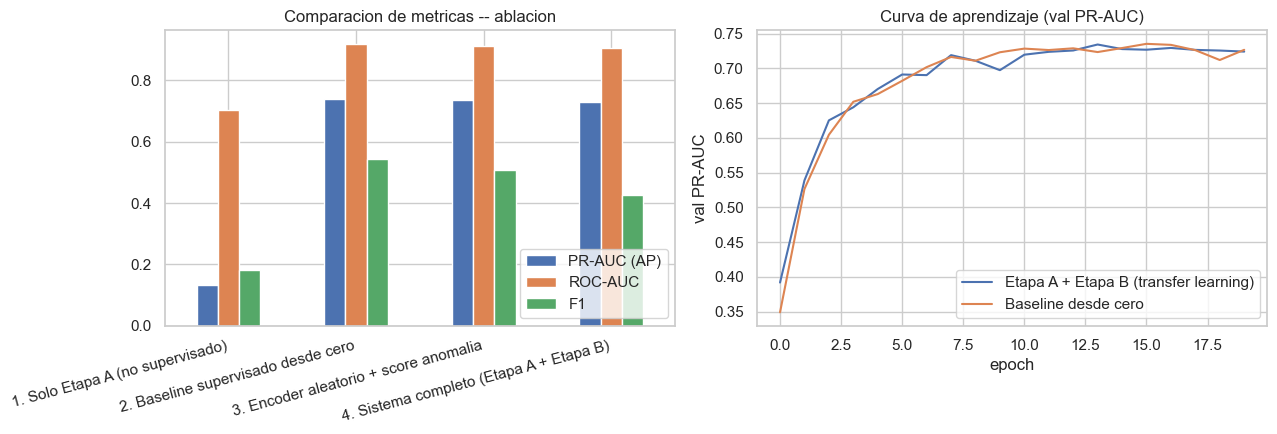

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ablation_table[["PR-AUC (AP)", "ROC-AUC", "F1"]].plot(kind="bar", ax=axes[0])
axes[0].set_title("Comparacion de metricas -- ablacion")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15, ha="right")
axes[0].legend(loc="lower right")

axes[1].plot(hist_two_stage["val_ap"], label="Etapa A + Etapa B (transfer learning)")
axes[1].plot(hist_baseline["val_ap"], label="Baseline desde cero")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("val PR-AUC")
axes[1].set_title("Curva de aprendizaje (val PR-AUC)")
axes[1].legend()

plt.tight_layout()
plt.savefig(DATA_PROCESSED / "ablation_comparison.png", dpi=120)
plt.show()

## 5. Guardar modelos y artefactos para el Componente 3 (interpretabilidad) y el MVP

In [15]:
MODELS_DIR = Path("../data/processed/models")
MODELS_DIR.mkdir(exist_ok=True)

torch.save(autoencoder.state_dict(), MODELS_DIR / "stage_a_autoencoder.pt")
torch.save(two_stage_model.state_dict(), MODELS_DIR / "stage_b_two_stage.pt")
torch.save(baseline_model.state_dict(), MODELS_DIR / "baseline_scratch.pt")
torch.save(score_only_model.state_dict(), MODELS_DIR / "score_only_scratch.pt")

all_scores["recon_error_z"] = all_scores["account"].map(recon_error_z_map)
all_scores["split"] = all_scores["account"].map(split_map)
all_scores.to_parquet(DATA_PROCESSED / "stage_a_scores.parquet", index=False)

ablation_table.to_csv(DATA_PROCESSED / "ablation_table.csv")
print(ablation_table.round(4))

import json
with open(MODELS_DIR / "config.json", "w") as f:
    json.dump({
        "MAX_SEQ_LEN": MAX_SEQ_LEN, "INPUT_DIM": INPUT_DIM, "HIDDEN_DIM": 64,
        "FEATURE_COLS": FEATURE_COLS, "N_TYPES": N_TYPES,
        "best_threshold_stage_a": float(best_threshold),
        "recon_error_mean_train": float(err_mean), "recon_error_std_train": float(err_std),
    }, f, indent=2)

print("Guardado en", MODELS_DIR, "y", DATA_PROCESSED)

                                         PR-AUC (AP)  ROC-AUC      F1  \
1. Solo Etapa A (no supervisado)              0.1333   0.7051  0.1819   
2. Baseline supervisado desde cero            0.7380   0.9174  0.5452   
3. Encoder aleatorio + score anomalia         0.7379   0.9118  0.5095   
4. Sistema completo (Etapa A + Etapa B)       0.7284   0.9075  0.4277   

                                         Precision  Recall  
1. Solo Etapa A (no supervisado)            0.1312  0.2964  
2. Baseline supervisado desde cero          0.4277  0.7518  
3. Encoder aleatorio + score anomalia       0.3879  0.7422  
4. Sistema completo (Etapa A + Etapa B)     0.2959  0.7711  
Guardado en ..\data\processed\models y ..\data\processed


## 6. Mecanismo de atencion, para interpretabilidad en el Componente 3

El TwoStageClassifier de las Secciones 3-4 usa solo el ultimo estado oculto del LSTM, sin pesos de atencion que inspeccionar.

Se anade atencion aditiva sobre los estados ocultos de cada paso: score_t = W*h_t, alpha = softmax(score) enmascarado en el padding, contexto = suma de alpha_t * h_t. alpha_t indica cuanto peso puso el clasificador en cada transaccion. Se reentrena con la misma configuracion ganadora de la Seccion 3.

In [16]:
class AttnTwoStageClassifier(nn.Module):
    """Igual que TwoStageClassifier, pero agrega (y expone) atencion aditiva sobre los pasos de tiempo del encoder."""
    def __init__(self, encoder, hidden_dim=64, use_anomaly_score=True):
        super().__init__()
        self.encoder = encoder
        self.attn = nn.Linear(hidden_dim, 1)
        self.use_anomaly_score = use_anomaly_score
        head_in = hidden_dim + (1 if use_anomaly_score else 0)
        self.head = nn.Sequential(nn.Linear(head_in, 32), nn.ReLU(), nn.Dropout(0.2), nn.Linear(32, 1))

    def pool(self, x, lengths):
        T = x.shape[1]
        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, _ = self.encoder(packed)
        out, _ = pad_packed_sequence(packed_out, batch_first=True, total_length=T)
        mask = sequence_mask(lengths, T, x.device)
        scores = self.attn(out).squeeze(-1)
        scores = scores.masked_fill(mask == 0, float("-inf"))
        alpha = torch.softmax(scores, dim=1)
        context = (alpha.unsqueeze(-1) * out).sum(dim=1)
        return context, alpha

    def forward(self, x, lengths, anomaly_score=None):
        context, _ = self.pool(x, lengths)
        z = torch.cat([context, anomaly_score.unsqueeze(1)], dim=1) if self.use_anomaly_score else context
        return self.head(z).squeeze(1)

    def forward_with_attention(self, x, lengths, anomaly_score=None):
        context, alpha = self.pool(x, lengths)
        z = torch.cat([context, anomaly_score.unsqueeze(1)], dim=1) if self.use_anomaly_score else context
        return self.head(z).squeeze(1), alpha


print("=== Entrenando clasificador CON atencion (encoder transferido + fine-tuning completo + score) ===")
transferred_encoder_attn = copy.deepcopy(autoencoder.encoder)
attn_model = AttnTwoStageClassifier(transferred_encoder_attn, hidden_dim=64, use_anomaly_score=True)
attn_model, hist_attn = train_classifier(
    attn_model, train_loader_full, val_loader_full,
    use_anomaly_score=True, n_epochs=20, lr_encoder=1e-3, lr_head=1e-3, pos_weight=pos_weight,
)

=== Entrenando clasificador CON atencion (encoder transferido + fine-tuning completo + score) ===


Epoch  1/20 | train BCE: 1.0726 | val AP (PR-AUC): 0.3929


Epoch  2/20 | train BCE: 0.8954 | val AP (PR-AUC): 0.5386


Epoch  3/20 | train BCE: 0.8022 | val AP (PR-AUC): 0.6112


Epoch  4/20 | train BCE: 0.7526 | val AP (PR-AUC): 0.6525


...

Epoch 16/20 | train BCE: 0.5472 | val AP (PR-AUC): 0.7197


Epoch 17/20 | train BCE: 0.5337 | val AP (PR-AUC): 0.7143


Epoch 18/20 | train BCE: 0.5194 | val AP (PR-AUC): 0.7142


Epoch 19/20 | train BCE: 0.5031 | val AP (PR-AUC): 0.7152


Epoch 20/20 | train BCE: 0.4875 | val AP (PR-AUC): 0.7084


In [17]:
metrics_attn, probs_attn, labs_attn = evaluate_on_test(
    predict_classifier(attn_model, test_loader_full, use_anomaly_score=True))
print("Metricas en test -- version CON atencion (mismo encoder/estrategia que la fila 4 de la ablacion):")
for k, v in metrics_attn.items():
    print(f"  {k}: {v:.4f}")
print()
print("Referencia sin atencion, fila 4 de la tabla de ablacion: PR-AUC ~0.728")
print("La version con atencion se usa en el Componente 3 por su interpretabilidad, no porque mejore la metrica de forma relevante.")

Metricas en test -- version CON atencion (mismo encoder/estrategia que la fila 4 de la ablacion):
  PR-AUC (AP): 0.7272
  ROC-AUC: 0.9057
  F1: 0.5036
  Precision: 0.3796
  Recall: 0.7482

Referencia sin atencion, fila 4 de la tabla de ablacion: PR-AUC ~0.728
La version con atencion se usa en el Componente 3 por su interpretabilidad, no porque mejore la metrica de forma relevante.


In [18]:
torch.save(attn_model.state_dict(), MODELS_DIR / "stage_b_attention.pt")
print("Guardado:", MODELS_DIR / "stage_b_attention.pt")

Guardado: ..\data\processed\models\stage_b_attention.pt
